# 📧 SMS Spam Classifier

## What This Project Does
In this project we will build a machine learning model that automatically detects whether a text message is **spam** (unwanted junk) or **ham** (a legitimate message). This is the same type of system used by messaging apps and mobile carriers to help identify unwanted SMS messages.

We will use the **SMS Spam Collection** dataset — a classic benchmark in text classification. We will clean the text, visualize it with word clouds, convert it to numerical features using TF-IDF, and train two models: **Naive Bayes** (a traditional approach for SMS spam filtering) and **Logistic Regression**.

## What You Will Learn
- What **ham** and **spam** mean in the context of SMS filtering
- How to handle **class imbalance** in a dataset
- How to generate **word clouds** to visualize the most common words
- Why **Naive Bayes** is a natural choice for text classification
- The critical difference between **false negatives and false positives** for spam detection

## Dataset
- **Source:** [SMS Spam Collection on Kaggle](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)
- **File to upload:** `spam.csv`

> 💡 **Tip:** Download the dataset from Kaggle before running this notebook.

In [ ]:
# ── STEP 1: Install Extra Libraries ──────────────────────────────────────────
# 'wordcloud' generates visual word clouds from text.
# 'nltk' provides stopwords and stemming tools.

!pip install -q wordcloud nltk

In [ ]:
# ── STEP 1 (continued): Import All Libraries ─────────────────────────────────

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud                             # Generates word cloud images

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB              # The Naive Bayes classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)

sns.set_theme(style='whitegrid')
print('✅ All libraries imported!')

✅ All libraries imported!


In [ ]:
# ── STEP 2: Upload the Dataset ────────────────────────────────────────────────
# Click 'Choose Files' and upload spam.csv.

uploaded = files.upload()
if not uploaded:
    raise ValueError('No file was uploaded. Please upload spam.csv to continue.')
filename = list(uploaded.keys())[0]
print(f'Uploaded: {filename}')

Saving archive (1).zip to archive (1).zip
Uploaded: archive (1).zip


In [ ]:
# ── STEP 2 (continued): Load and Clean Up the Dataset ────────────────────────
# spam.csv uses Latin-1 encoding and has 5 columns, but only the first two
# matter: the label ('ham' or 'spam') and the message text.
# The remaining 3 columns (Unnamed:2, 3, 4) are mostly empty — we drop them.

df = pd.read_csv(filename, encoding='latin-1', header=0)

# Keep only the first two columns and rename them to sensible names
df = df.iloc[:, :2]
df.columns = ['label', 'text']

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(df.head())

Shape: (5572, 2)
Columns: ['label', 'text']
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
# ── STEP 3: Convert Labels to Numbers ────────────────────────────────────────
# The labels are currently text strings: 'ham' and 'spam'.
# ML models need numbers, so we convert:
#   • 'ham'  → 0  (legitimate message)
#   • 'spam' → 1  (unwanted junk)
#
# What does 'ham' mean?
# 'Ham' is an informal term used by email/SMS researchers to describe a WANTED,
# legitimate message — the opposite of spam. The term has been used in anti-spam
# research since the early 2000s. It may originate from the phrase 'ham radio'
# (amateur radio operators who communicate with real intent).

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print('Label mapping: ham=0, spam=1')
print(df['label'].value_counts())

Label mapping: ham=0, spam=1
label
0    4825
1     747
Name: count, dtype: int64


/tmp/ipykernel_8803/799890043.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=['Ham (0)', 'Spam (1)'], y=counts.values, palette='Set2')


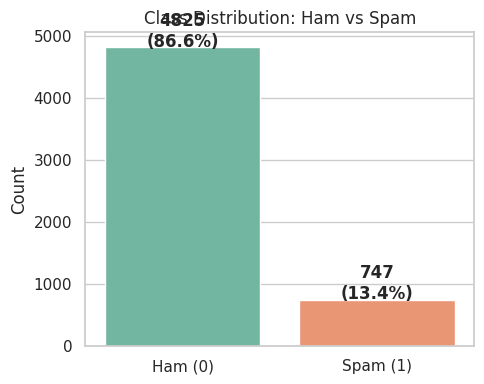

Notice: ~87% ham, ~13% spam — this is an imbalanced dataset!


In [ ]:
# ── STEP 4: Class Distribution Bar Chart ─────────────────────────────────────
# Class imbalance occurs when one class has far more samples than the other.
# This dataset has ~87% ham and ~13% spam — a significant imbalance.
#
# Why does class imbalance matter?
#   If we just predicted 'ham' for everything, we'd be 'right' 87% of the time —
#   but we would miss every single spam message! A model trained naively might
#   learn this shortcut. We should use precision/recall/F1 rather than just
#   accuracy to evaluate our spam detector.

counts = df['label'].value_counts()
percentages = df['label'].value_counts(normalize=True) * 100

plt.figure(figsize=(5, 4))
bars = sns.barplot(x=['Ham (0)', 'Spam (1)'], y=counts.values, palette='Set2')
plt.title('Class Distribution: Ham vs Spam')
plt.ylabel('Count')
for i, (v, p) in enumerate(zip(counts.values, percentages.values)):
    plt.text(i, v + 10, f'{v}\n({p:.1f}%)', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print('Notice: ~87% ham, ~13% spam — this is an imbalanced dataset!')

In [ ]:
# ── STEP 5: Text Cleaning Function ───────────────────────────────────────────
# Raw SMS messages contain punctuation, capitals, and filler words that add
# noise without helping the model learn what makes a message spam.
# Our cleaning pipeline:
#   1. Lowercase — so 'Free' and 'free' are treated as the same word
#   2. Remove punctuation — '!!!' and '.' carry no semantic meaning for TF-IDF
#   3. Remove stopwords — 'the', 'is', 'and' appear in all messages equally
#   4. Stemming — reduces 'winning', 'winner', 'won' to 'win'

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Clean a single SMS message string."""
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove punctuation and numbers (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 3: Tokenize (split into individual words)
    words = text.split()

    # Step 4: Remove stopwords and apply stemming
    words = [stemmer.stem(w) for w in words if w not in stop_words]

    return ' '.join(words)

print('✅ clean_text() defined!')

✅ clean_text() defined!


In [ ]:
# ── STEP 6: Apply Cleaning and Show Before/After ──────────────────────────────

df['clean_text'] = df['text'].apply(clean_text)

print('=== Before & After Cleaning (5 examples) ===')
for i in range(5):
    label_name = 'SPAM' if df['label'].iloc[i] == 1 else 'HAM'
    print(f'\n[{label_name}] Original : {df["text"].iloc[i]}')
    print(f'[{label_name}] Cleaned  : {df["clean_text"].iloc[i]}')
    print('-' * 70)

=== Before & After Cleaning (5 examples) ===

[HAM] Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
[HAM] Cleaned  : go jurong point crazi avail bugi n great world la e buffet cine got amor wat
----------------------------------------------------------------------

[HAM] Original : Ok lar... Joking wif u oni...
[HAM] Cleaned  : ok lar joke wif u oni
----------------------------------------------------------------------

[SPAM] Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
[SPAM] Cleaned  : free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over
----------------------------------------------------------------------

[HAM] Original : U dun say so early hor... U c already then say...
[HAM] Cleaned  : u dun say earli hor u c alreadi say
-------------

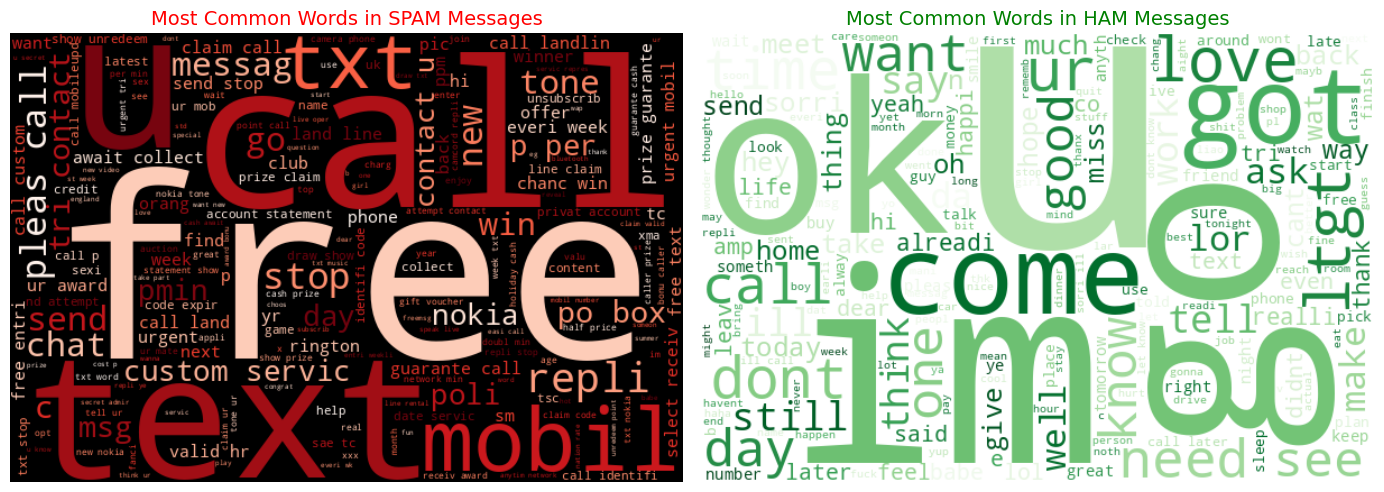

Spam often features words like: free, call, win, prize, claim, text
Ham often features words like: ok, go, come, know, good, time


In [ ]:
# ── STEP 7: Word Clouds for Spam and Ham ─────────────────────────────────────
# A word cloud displays words in sizes proportional to how frequently they
# appear in the text. Larger words = more common. This is a quick visual way
# to understand what topics/words dominate spam vs ham messages.

spam_text = ' '.join(df[df['label'] == 1]['clean_text'].values)
ham_text  = ' '.join(df[df['label'] == 0]['clean_text'].values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Spam word cloud
spam_wc = WordCloud(width=600, height=400, background_color='black', colormap='Reds').generate(spam_text)
axes[0].imshow(spam_wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Common Words in SPAM Messages', fontsize=14, color='red')

# Ham word cloud
ham_wc = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(ham_text)
axes[1].imshow(ham_wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Common Words in HAM Messages', fontsize=14, color='green')

plt.tight_layout()
plt.show()
print('Spam often features words like: free, call, win, prize, claim, text')
print('Ham often features words like: ok, go, come, know, good, time')

In [ ]:
# ── STEP 8: TF-IDF Vectorizer Setup ──────────────────────────────────────────
# TF-IDF (Term Frequency – Inverse Document Frequency) converts our cleaned
# text into a numerical matrix that ML models can process.
#
# For each word in each message:
#   • TF (Term Frequency) = how often this word appears in THIS message
#   • IDF (Inverse Document Frequency) = log(total messages / messages containing this word)
#   • TF-IDF = TF × IDF
#
# Words that appear in almost every message get a low IDF (e.g. 'ok', 'I').
# Words that appear in only a few specific messages get a high IDF (e.g. 'prize').
# These discriminating words are more useful for detecting spam.
#
# IMPORTANT — We only *initialise* the vectorizer here.
# We must split the data first and then fit the vectorizer on the training set
# only. Fitting on all data before the split would leak IDF statistics from the
# test set into training, making evaluation results over-optimistic.

tfidf = TfidfVectorizer(max_features=5000)
y = df['label'].values

print(f'Labels extracted: {len(y)} messages ({y.sum()} spam, {(y == 0).sum()} ham)')

Labels extracted: 5572 messages (747 spam, 4825 ham)


In [ ]:
# ── STEP 9: Train / Test Split and TF-IDF Vectorization ──────────────────────
# We split the RAW TEXT first, then fit TF-IDF only on the training messages.
# This prevents data leakage: IDF statistics (how rare each word is) should
# be computed from training data only. Using the full dataset before the split
# would let test-set vocabulary influence the model and inflate metrics.
#
# stratify=y ensures the same spam/ham ratio appears in both train and test
# sets — important because the dataset is heavily imbalanced (~87% ham).

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'], y, test_size=0.2, random_state=42, stratify=y
)

# fit_transform: learns vocabulary/IDF from training messages, then transforms them
X_train = tfidf.fit_transform(X_train_text)
# transform: applies the SAME vocabulary/IDF to test messages (no re-learning)
X_test  = tfidf.transform(X_test_text)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 4457 | Test: 1115


In [ ]:
# ── STEP 10: Naive Bayes Classifier ──────────────────────────────────────────
# Naive Bayes is one of the oldest and most effective algorithms for text
# classification — it literally powered the first spam filters in the 1990s.
#
# Why does Naive Bayes work well for text?
#   • It uses Bayes' theorem: P(spam | words) ∝ P(words | spam) × P(spam)
#   • It calculates the probability that a message is spam given the words in it
#   • The 'naive' part: it assumes each word is independent of the others
#     (not always true, but a good enough approximation for short messages)
#   • It's extremely fast to train and predict
#   • MultinomialNB is specifically designed for word counts/frequencies

nb = MultinomialNB()
nb.fit(X_train, y_train)

nb_acc = accuracy_score(y_test, nb.predict(X_test))
print(f'Naive Bayes Accuracy: {nb_acc:.4f} ({nb_acc*100:.1f}%)')

Naive Bayes Accuracy: 0.9641 (96.4%)


In [ ]:
# ── STEP 11: Logistic Regression and Comparison ───────────────────────────────
# Logistic Regression learns a weighted combination of TF-IDF features to
# predict the spam probability. Unlike Naive Bayes, it doesn't assume
# independence between words, so it can sometimes capture richer patterns.

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f'Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.1f}%)')
print(f'Naive Bayes Accuracy         : {nb_acc:.4f} ({nb_acc*100:.1f}%)')

Logistic Regression Accuracy: 0.9659 (96.6%)
Naive Bayes Accuracy         : 0.9641 (96.4%)


In [ ]:
# ── STEP 12: Classification Report — What Precision and Recall Mean Here ──────
# For a spam detector, precision and recall have very specific real-world meanings:
#
# • Precision for spam (class 1):
#   Of all messages flagged as spam, what fraction are actually spam?
#   LOW precision → legitimate emails end up in the spam folder (annoying!)
#
# • Recall for spam (class 1):
#   Of all actual spam messages, what fraction did we catch?
#   LOW recall → spam messages slip through to the inbox (dangerous!)
#
# There is a trade-off: increasing one often decreases the other.
# Gmail and Outlook tune this to prefer high precision (don't block legitimate emails).

best_model = lr if lr_acc >= nb_acc else nb
best_name  = 'Logistic Regression' if lr_acc >= nb_acc else 'Naive Bayes'
y_pred = best_model.predict(X_test)

print(f'=== Classification Report ({best_name}) ===')
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

=== Classification Report (Logistic Regression) ===
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.99      0.75      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



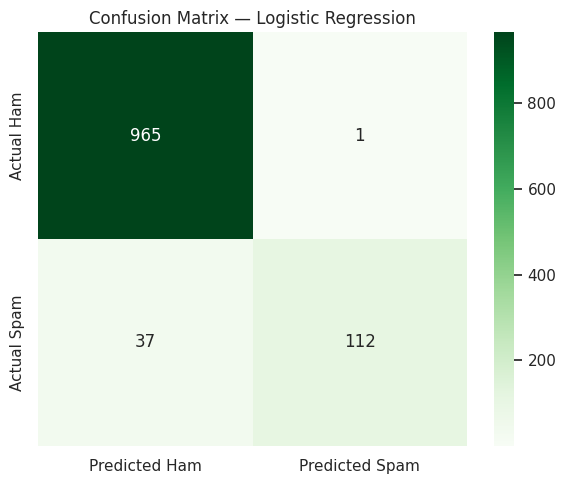

In [ ]:
# ── STEP 13: Confusion Matrix and Cost of Errors ─────────────────────────────
# The confusion matrix shows us the 4 types of outcomes:
#
# • True Negative  (Ham predicted as Ham)   → Correct! 🟢
# • True Positive  (Spam predicted as Spam) → Correct! 🟢
# • False Positive (Ham predicted as Spam)  → WRONG: a real email goes to spam folder 🟡
#   This is called a 'Type I error' or a 'false alarm'
# • False Negative (Spam predicted as Ham)  → WRONG: spam gets through to inbox 🔴
#   This is called a 'Type II error' or a 'miss'
#
# In most spam filter applications:
#   False Negative (missing spam) is annoying but manageable.
#   False Positive (blocking real email) is WORSE — you might miss important messages!
# That's why commercial spam filters are tuned for HIGH precision.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()